# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [82]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from tkinter import messagebox
import numpy as np

### 1. Matrices de Transición

#### A) Matriz de Transición Original (Recurrente Continua)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
q & p & 0 & 0 & \cdots & 0 & 0 
\end{pmatrix}$$

#### B) Matriz de Transición Modificada (Absorbente)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 
\end{pmatrix}$$

In [98]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    q = 1 - p
    P = np.zeros((N + 1, N + 1))

    for estado_actual in range(N):
        P[estado_actual, estado_actual + 1] = p      # Éxito
        P[estado_actual, 0]                 = q      # Fracaso

    P[N, 1] = p      # Éxito
    P[N, 0] = q      # Fracaso
    
    return P

N = 5     # RACHA DE N LONGITUD A CONSEGUIR
matriz_P = construir_matriz_transicion(p, N)

# Matriz absorbente
matriz_P_absorbente = matriz_P.copy()
matriz_P_absorbente[N, :] = 0.0  
matriz_P_absorbente[N, N] = 1.0   # 1 en la diagonal para hacer el estado N absorbente

def imprimir_matriz(matriz):
    # Estados destino
    print(" " * 15, end="")
    for destino in range(matriz.shape[1]):
        print(f"   {destino:^5}   ", end="")
    print("\n" + "-" * (15 + 8 * matriz.shape[1]))

    # Filas de la matriz
    for origen in range(matriz.shape[0]):
        print(f"      Estado {origen}     |", end="")
        for destino in range(matriz.shape[1]):
            valor = matriz[origen, destino]
            print(f"   {valor:5.2f}  ", end="")
        print()
    print("\n")

# Imprimir ambas versiones
imprimir_matriz(matriz_P)
imprimir_matriz(matriz_P_absorbente)

                    0          1          2          3          4          5     
---------------------------------------------------------------
      Estado 0     |    0.30      0.70      0.00      0.00      0.00      0.00  
      Estado 1     |    0.30      0.00      0.70      0.00      0.00      0.00  
      Estado 2     |    0.30      0.00      0.00      0.70      0.00      0.00  
      Estado 3     |    0.30      0.00      0.00      0.00      0.70      0.00  
      Estado 4     |    0.30      0.00      0.00      0.00      0.00      0.70  
      Estado 5     |    0.30      0.70      0.00      0.00      0.00      0.00  


                    0          1          2          3          4          5     
---------------------------------------------------------------
      Estado 0     |    0.30      0.70      0.00      0.00      0.00      0.00  
      Estado 1     |    0.30      0.00      0.70      0.00      0.00      0.00  
      Estado 2     |    0.30      0.00      0.00      0.70

### 2. Parámetros iniciales y simulación

['p', 'p', 'q', 'p', 'p', 'p', 'p', 'q', 'p', 'p', 'p', 'p', 'p']


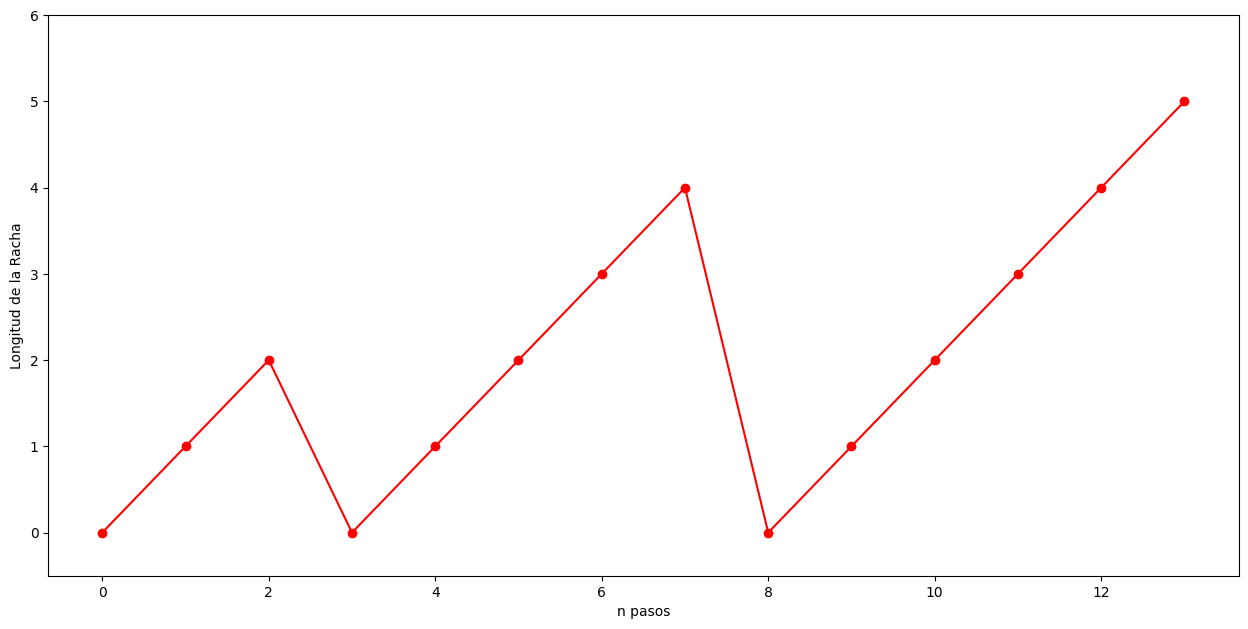

In [95]:
p = 0.7   # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 

racha_actual = 0
historial_rachas = [0]
historial_letras = [] 
corriendo = False

def simular_paso():
    global racha_actual, corriendo
    
    if not corriendo:
        return  

    modo_elegido = combo_modo.get()

    # Ensayo de Bernoulli
    val = random.random()
    if val < p:
        historial_letras.append('p') 
        
        if modo_elegido == "Infinito":
            if racha_actual == 5:
                racha_actual = 1  
            else:
                racha_actual += 1
                
        elif modo_elegido == "Absorbente":
            racha_actual += 1  
            
    else:
        historial_letras.append('q') 
        racha_actual = 0  

    # Guardar historial para la gráfica
    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:  
        historial_rachas.pop(0)

    # Actualizar la gráfica
    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("Longitud de la Racha")
    ax.set_xlabel("n pasos") 
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, 5))
    canvas.draw()

    # Parar en el caso finito absorbente al alcanzar la racha
    if modo_elegido == "Absorbente" and racha_actual == 5:
        corriendo = False
        boton_iniciar.config(state="normal")
        boton_parar.config(state="disabled")
        combo_modo.config(state="readonly") 
        print(historial_letras)
        return

    ventana.after(500, simular_paso)

# Interfaz gráfica
def iniciar():
    global corriendo, racha_actual, historial_rachas, historial_letras
    if not corriendo:
        racha_actual = 0
        historial_rachas = [0]
        historial_letras = []
        
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        combo_modo.config(state="disabled") 
        simular_paso()

def parar():
    global corriendo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")
    combo_modo.config(state="readonly") 
    print(historial_letras)

ventana = tk.Tk()
ventana.title("Simulador de Rachas de Éxitos")
ventana.geometry("750x550")

frame_controles = ttk.Frame(ventana)
frame_controles.pack(pady=15)

# Menú desplegable 
combo_modo = ttk.Combobox(frame_controles, values=["Infinito", "Absorbente"], width=20)
combo_modo.current(0) 
combo_modo.config(state="readonly")
combo_modo.pack(side="left", padx=10)

boton_iniciar = ttk.Button(frame_controles, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=5)

boton_parar = ttk.Button(frame_controles, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=5)

# Contenedor de la gráfica de Matplotlib
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

ax.plot(historial_rachas)
ax.set_ylabel("longitud de la Racha")
ax.set_xlabel("n pasos")
canvas.draw()

ventana.mainloop()

### 3. Clases de comunicación

In [70]:
letras_simuladas = historial_letras

# Rachas paso a paso (¡AHORA CON REGLA LUIS RINCÓN!)
rachas_paso_a_paso = [0]
racha_actual = 0
for letra in letras_simuladas:
    if letra == 'p':
        if racha_actual == 5:
            racha_actual = 1  # Si ya estás en 5 y ganas, bajas a 1 estilo el mono
        else:
            racha_actual += 1  # Si no, subes normalmente
    else:
        racha_actual = 0  # Fracaso: colapsas a cero
    rachas_paso_a_paso.append(racha_actual)

# El resto de tu código para conexiones y clases se queda EXACTAMENTE IGUAL:
conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles de la simulación:")
for origen, destino in sorted(conexiones_encontradas):
    print(f" {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))

print("\nClases de comunicación:")
cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
print(f"  {cadena_igualdad}")

Estados accesibles de la simulación:
 0 a 1
 1 a 0
 1 a 2
 2 a 0
 2 a 3
 3 a 4
 4 a 0
 4 a 5
 5 a 1

Clases de comunicación:
  C(0) = C(1) = C(2) = C(3) = C(4) = C(5)


### 4. Clasificación de los estados

In [74]:
suma_infinito = q * (1 / (1 - p))

print(f"Probabilidad total de retorno al origen (f_00): {suma_infinito:.1f}")

estados_analizados = estados_visitados

for estado in estados_analizados:
    if abs(suma_infinito - 1.0) < 1e-9:
        tipo_clasificacion = "Recurrente Positivo"
    else:
        tipo_clasificacion = "Transitorio"
        
    print(f"Estado {estado} : {tipo_clasificacion}")

Probabilidad total de retorno al origen (f_00): 1.0
Estado 0 : Recurrente Positivo
Estado 1 : Recurrente Positivo
Estado 2 : Recurrente Positivo
Estado 3 : Recurrente Positivo
Estado 4 : Recurrente Positivo
Estado 5 : Recurrente Positivo


### 5. Periodos de los estados de la cadena